# Dataset & DataLoader

In [1]:
import os
import random

import numpy as np

import torch
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T

from dataset_fixed import TrainDataset, TestDataset

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for this script because the submission block uses .cuda().")

device = torch.device("cuda")

In [3]:
image_size = 64
batch_size_train = 32
batch_size_eval = 32

mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

val_ratio = 0.20
epochs = 15
label_smoothing = 0.1

save_path = "best_model.pth"

In [4]:
# data augmentation
train_transform = T.Compose([
    T.Pad(4, padding_mode='reflect'),
    T.RandomCrop(image_size),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(7),
    T.ColorJitter(brightness=0.02, contrast=0.02, saturation=0.02, hue=0.01),
    T.RandomGrayscale(p=0.02),
    T.ToTensor(),
    T.Normalize(mean, std),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std),
])

In [5]:
data_root = "./cs441-assn3-data"

train_dataset_aug  = TrainDataset(root_path=data_root, transform=train_transform)
train_dataset_eval = TrainDataset(root_path=data_root, transform=eval_transform)
test_dataset = TestDataset(root_path=data_root, transform=eval_transform)

In [6]:
def stratified_split(labels: np.ndarray, val_ratio: float, seed: int):
    """Return (train_indices, val_indices) with per-class stratification.
    No sklearn dependency.
    """
    rng = np.random.default_rng(seed)
    labels = labels.astype(int)
    classes, counts = np.unique(labels, return_counts=True)

    val_indices = []
    train_indices = []

    for c, cnt in zip(classes, counts):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)
        n_val_c = int(round(cnt * val_ratio))
        # keep at least 1 sample in train if possible
        n_val_c = min(max(n_val_c, 1), max(cnt - 1, 1))
        val_indices.extend(idx[:n_val_c].tolist())
        train_indices.extend(idx[n_val_c:].tolist())

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    return train_indices, val_indices

In [7]:
labels = np.array(train_dataset_eval.labels, dtype=int)
train_indices, val_indices = stratified_split(labels, val_ratio=val_ratio, seed=SEED)

train_subset = Subset(train_dataset_aug, train_indices)
val_subset   = Subset(train_dataset_eval, val_indices)

num_workers = min(8, os.cpu_count() or 4)

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size_train,
    shuffle=True,
    num_workers=num_workers,
    drop_last=False,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size_eval,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size_eval,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
)

# Your Awesome Model

In [8]:
from res2nextse_large import res2nextse101

In [9]:
model = res2nextse101(num_classes=15, groups=1, scale=4).to(device)

# Model parameter checking

In [10]:
# model parameters checking
num_params = sum(p.numel() for p in model.parameters())
print('The number of your model parameters :', num_params)
print('Parameter usage : ' + str(num_params/1000000) + '%')
if num_params > 100000000:
  raise Exception('Compress your model.')

The number of your model parameters : 29920111
Parameter usage : 29.920111%


# Model training

In [11]:
import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

In [12]:
print("GPU count:", torch.cuda.device_count())
print("Current device index:", torch.cuda.current_device())
print("Current device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

GPU count: 1
Current device index: 0
Current device name: NVIDIA GeForce RTX 4080 SUPER


In [13]:
MAX_LR_STABLE = 1e-3 # 최대 LR (0.001)
BASE_LR_MIN = 5e-5   # 최소 LR (Max_LR의 약 1/20)
SGD_MAX_LR = 0.1
SGD_WD = 5e-4 # SGD는 WD를 낮게 씁니다.

# 옵티마이저 설정 (최소 LR로 시작)
optimizer = optim.SGD(
    model.parameters(), 
    lr=BASE_LR_MIN,
    momentum=0.9, 
    weight_decay=SGD_WD
)

# 스케줄러 설정 (최대 LR로 점프)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=SGD_MAX_LR,
    epochs=epochs, 
    steps_per_epoch=len(train_loader),
    pct_start=0.3, 
    div_factor=SGD_MAX_LR / BASE_LR_MIN,
    final_div_factor=2000, 
)

criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing).to(device)
scaler = torch.amp.GradScaler("cuda")

best_val_acc = -1.0

In [14]:
print("Start Training...")

for epoch in range(epochs):
    # TRAIN
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for x, y in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast("cuda"):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        
        scaler.step(optimizer)
        scaler.update()
        scheduler.step() 
        
        pred = out.argmax(dim=1)        
        train_loss_sum += loss.item() * x.size(0)
        train_correct += (pred == y).sum().item()
        train_total += x.size(0)

    # epochs 통계 출력
    train_loss = train_loss_sum / max(1, train_total)
    train_acc = train_correct / max(1, train_total)
    
    # VALIDATION
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            out = model(x)
            loss = criterion(out, y)

            val_loss_sum += loss.item() * y.size(0)
            val_correct += (out.argmax(1) == y).sum().item()
            val_total += y.size(0)

    val_loss = val_loss_sum / max(1, val_total)
    val_acc = val_correct / max(1, val_total)
    
    # 한 줄로 깔끔하게 출력
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    # Best Model 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  >>> Saved Best Model (Val Acc: {val_acc:.4f})")
    
    # 마지막 모델 저장
    torch.save(model.state_dict(), "last_model.pth")

Start Training...


Epoch 1/15 [Train]:   0%|          | 0/1125 [00:00<?, ?it/s]c:\Users\user\miniconda3\envs\jupyter\lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 01 | Train Loss: 2.6750 Acc: 0.1402 | Val Loss: 2.5985 Acc: 0.2372
  >>> Saved Best Model (Val Acc: 0.2372)


Epoch 02 | Train Loss: 2.3094 Acc: 0.2895 | Val Loss: 2.6011 Acc: 0.3317
  >>> Saved Best Model (Val Acc: 0.3317)


Epoch 03 | Train Loss: 2.0895 Acc: 0.3785 | Val Loss: 2.0977 Acc: 0.3803
  >>> Saved Best Model (Val Acc: 0.3803)


...

Epoch 11 | Train Loss: 1.4954 Acc: 0.6222 | Val Loss: 1.5951 Acc: 0.5872
  >>> Saved Best Model (Val Acc: 0.5872)


Epoch 12 | Train Loss: 1.4281 Acc: 0.6497 | Val Loss: 1.3974 Acc: 0.6640
  >>> Saved Best Model (Val Acc: 0.6640)


Epoch 13 | Train Loss: 1.3318 Acc: 0.6874 | Val Loss: 1.2838 Acc: 0.7072
  >>> Saved Best Model (Val Acc: 0.7072)


Epoch 14 | Train Loss: 1.1987 Acc: 0.7425 | Val Loss: 1.1540 Acc: 0.7588
  >>> Saved Best Model (Val Acc: 0.7588)


Epoch 15 | Train Loss: 1.0724 Acc: 0.7993 | Val Loss: 1.1011 Acc: 0.7803
  >>> Saved Best Model (Val Acc: 0.7803)


In [15]:
model.load_state_dict(torch.load(save_path, map_location=device))

C:\Users\user\AppData\Local\Temp\ipykernel_8376\1058478286.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_location=devic

<All keys matched successfully>

Extracting Validation Logits...
Extracting features from loader...



[Softmax Classifier] Validation Accuracy: 0.7803

Softmax Acc: 0.7803


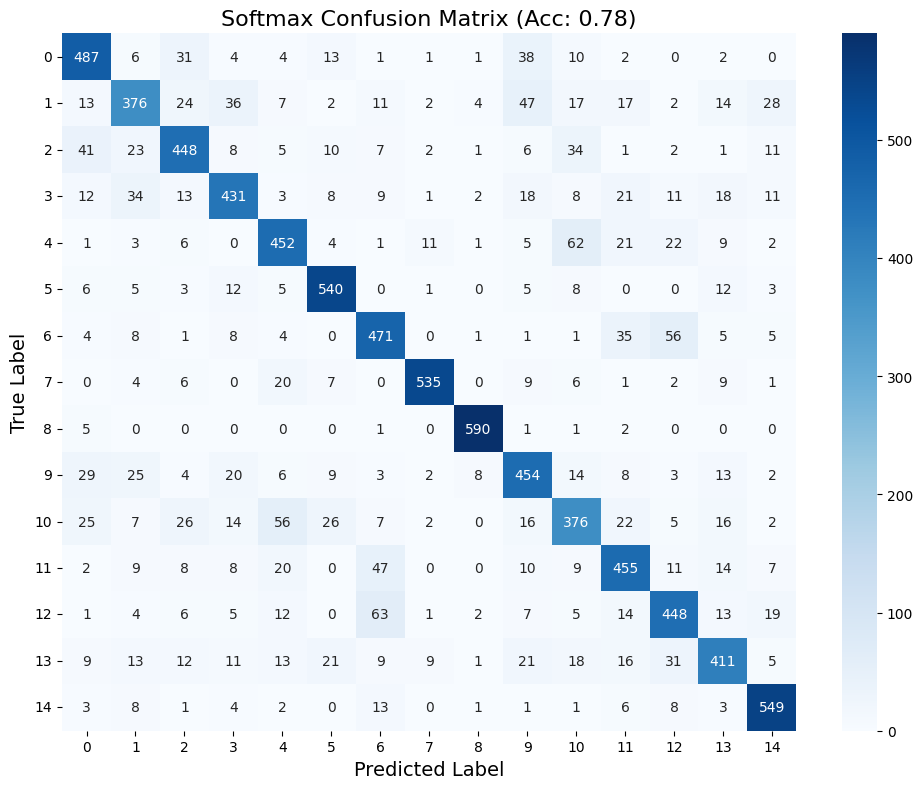


Classification Report (Softmax):
              precision    recall  f1-score   support

           0       0.76      0.81      0.79       600
           1       0.72      0.63      0.67       600
           2       0.76      0.75      0.75       600
           3       0.77      0.72      0.74       600
           4       0.74      0.75      0.75       600
           5       0.84      0.90      0.87       600
           6       0.73      0.79      0.76       600
           7       0.94      0.89      0.92       600
           8       0.96      0.98      0.97       600
           9       0.71      0.76      0.73       600
          10       0.66      0.63      0.64       600
          11       0.73      0.76      0.75       600
          12       0.75      0.75      0.75       600
          13       0.76      0.69      0.72       600
          14       0.85      0.92      0.88       600

    accuracy                           0.78      9000
   macro avg       0.78      0.78      0.78   

In [16]:
import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch

target_names = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 
    '10', '11', '12', '13', '14'
]

def get_logits(model, loader, device):
    model.eval()
    logits_list = []
    labels_list = []
    
    print(f"Extracting features from loader...")
    with torch.no_grad():
        for x, y in tqdm.tqdm(loader, leave=False):
            x = x.to(device)
            out = model(x)
            
            logits_list.append(out.detach().cpu().numpy())
            labels_list.append(y.detach().cpu().numpy())
    
    # 리스트를 하나의 거대한 Numpy 배열로 병합
    logits = np.concatenate(logits_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    
    return logits, labels

# 메인 실행
print("Extracting Validation Logits...")
val_logits, y_val = get_logits(model, val_loader, device) 

num_samples = 9000
num_classes = 15
val_preds_softmax = np.argmax(val_logits, axis=1)
acc_softmax = accuracy_score(y_val, val_preds_softmax)

# Logits에서 가장 큰 값을 가진 인덱스가 예측값
val_preds_softmax = np.argmax(val_logits, axis=1)
acc_softmax = accuracy_score(y_val, val_preds_softmax)

print(f"\n[Softmax Classifier] Validation Accuracy: {acc_softmax:.4f}")

# 혼동 행렬 시각화
print("\n" + "="*50)
print(f"Softmax Acc: {acc_softmax:.4f}")
print("="*50)

fig, ax = plt.subplots(figsize=(10, 8)) 

# Softmax Confusion Matrix 계산 및 시각화
cm_softmax = confusion_matrix(y_val, val_preds_softmax)
sns.heatmap(
    cm_softmax,
    annot=True, # 셀 안에 숫자 표시
    fmt='d',    # 정수 형식으로 표시
    cmap='Blues', 
    ax=ax,
    xticklabels=target_names, # x축 레이블 설정
    yticklabels=target_names  # y축 레이블 설정
)
ax.set_title(f'Softmax Confusion Matrix (Acc: {acc_softmax:.2f})', fontsize=16)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.yticks(rotation=0) # y축 레이블이 잘 보이도록 회전 조정

plt.tight_layout()
plt.show()

# 상세 리포트 출력
print("\nClassification Report (Softmax):")
print(classification_report(y_val, val_preds_softmax, target_names=target_names))

# Submit
Do not edit the submission code below.

In [17]:
import pandas as pd

# Load Best Model
submit = pd.read_csv('./cs441-assn3-data/Test_64.csv')

# model parameters checking
num_params = sum(p.numel() for p in model.parameters())
print('The number of your model parameters :', num_params)
print('Parameter usage : ' + str(num_params/1000000) + '%')
if num_params > 100000000:
  raise Exception('Compress your model.')

total_prediction = list()
model.eval()
with torch.no_grad():
    for x in tqdm.tqdm(test_loader):
        x = torch.FloatTensor(x).cuda()
        output = model(x)
        predict = torch.argmax(output,dim=1)
        total_prediction.extend(predict.cpu().numpy())
    submit['label'] = total_prediction
    submit.to_csv('submission.csv',index=False)

The number of your model parameters : 29920111
Parameter usage : 29.920111%


100%|██████████| 235/235 [00:27<00:00,  8.45it/s]
